In [1]:
import torch
from torchvision import datasets, transforms

In [2]:
data_transform = transforms.Compose([transforms.Resize((224,224)),
                                transforms.ToTensor()])

In [4]:
from OxfordDataLoader import OxfordPetsDataset


full_dataset = OxfordPetsDataset(root_dir='res', transform=data_transform)

print(f"Dataset caricato! Trovate {len(full_dataset)} immagini.")

# Divisione Train/Val/Test (opzionale ma consigliata)
# Esempio: 80% training, 20% validation
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(full_dataset, [train_size, test_size])

# Creazione dei DataLoader
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)

Dataset caricato! Trovate 7349 immagini.


['Abyssinian_100', '1', '1', '1']
['Abyssinian_101', '1', '1', '1']
['Abyssinian_102', '1', '1', '1']
['Abyssinian_103', '1', '1', '1']
['Abyssinian_104', '1', '1', '1']
['Abyssinian_105', '1', '1', '1']
['Abyssinian_106', '1', '1', '1']
['Abyssinian_107', '1', '1', '1']
['Abyssinian_108', '1', '1', '1']
['Abyssinian_109', '1', '1', '1']
['Abyssinian_10', '1', '1', '1']
['Abyssinian_110', '1', '1', '1']
['Abyssinian_111', '1', '1', '1']
['Abyssinian_112', '1', '1', '1']
['Abyssinian_113', '1', '1', '1']
['Abyssinian_114', '1', '1', '1']
['Abyssinian_115', '1', '1', '1']
['Abyssinian_116', '1', '1', '1']
['Abyssinian_117', '1', '1', '1']
['Abyssinian_118', '1', '1', '1']
['Abyssinian_119', '1', '1', '1']
['Abyssinian_11', '1', '1', '1']
['Abyssinian_120', '1', '1', '1']
['Abyssinian_121', '1', '1', '1']
['Abyssinian_122', '1', '1', '1']
['Abyssinian_123', '1', '1', '1']
['Abyssinian_124', '1', '1', '1']
['Abyssinian_125', '1', '1', '1']
['Abyssinian_126', '1', '1', '1']
['Abyssinian_127

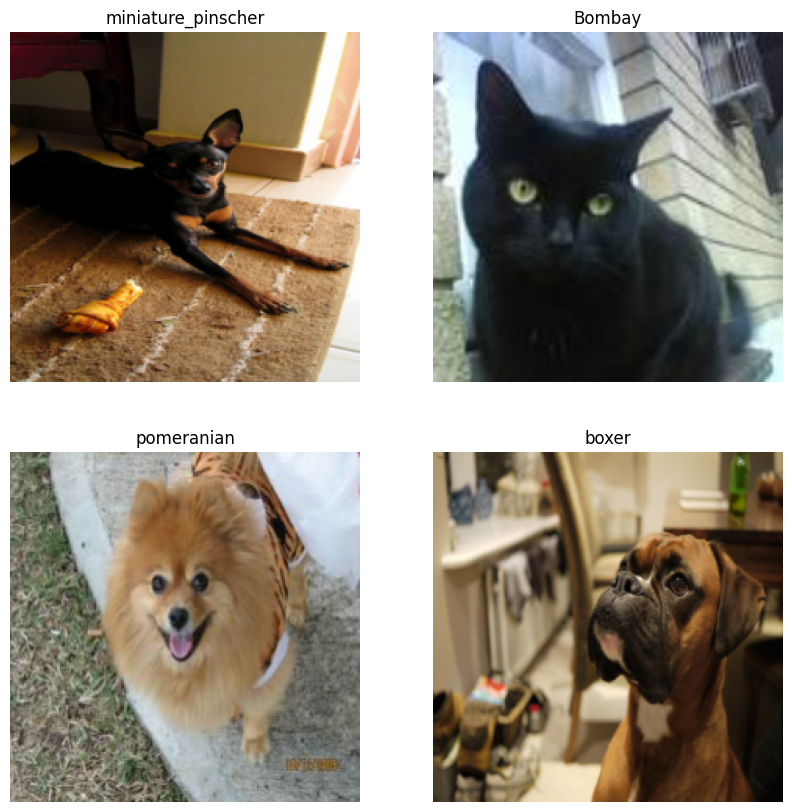

In [ ]:
import matplotlib.pyplot as plt
import torch

#Scegliamo qualche immagine da mostare per verificare che matchino le annotazioni

idx_to_class = {}
with open('res/annotations/list.txt', 'r') as f:
    for line in f:
        if line.startswith('#'): continue
        parts = line.strip().split()
        if len(parts) >= 2:
            breed_name = parts[0].rsplit('_', 1)[0] 
            class_id = int(parts[1]) - 1 
            idx_to_class[class_id] = breed_name

figure = plt.figure(figsize=(10, 10))
cols, rows = 2, 2

for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(full_dataset), size=(1,)).item()
    
    img, label = full_dataset[sample_idx]
    
    figure.add_subplot(rows, cols, i)
    
    plt.title(f"{idx_to_class.get(label, label)} (ID: {label})")
    plt.axis("off")
    
    plt.imshow(img.permute(1, 2, 0))

plt.show()